# Estimation de Matrices de Covariance

Il est bien connu qu'une bonne estimation de la volatilité permet une modélisation plus précise des rendements et des investissements plus stable donc des rendements plus grands. Cependant, prédire la volatilité avec précision est une problème difficile.


## Mesurer la volatilité


La volatilité doit être prospective et prédictive afin de permettre une prise de décision pertinente. Malheureusement, le simple fait de prendre l'écart-type historique des rendements d'un actif individuel est insuffisant si on veut avoir de la robustesse par rapport aux valeurs futures. Le problème de prédiction de  la volatilité de plusieurs actifs est encore plus difficile.

Pour modéliser l'évolution globale d'un portefeuille, il est important d'examiner non seulement la volatilité de chaque actif du portefeuille, mais également les covariances mutuelles des actifs en question. La relation entre deux ou plusieurs actifs fournit des informations précieuses et une voie vers la réduction de la volatilité globale du portefeuille. Un grand nombre d'actifs à faible covariance assurerait qu'ils diminuent ou augmentent indépendamment les uns des autres.


## Covariance

En statistiques et probabilités, la covariance est une mesure de la variabilité conjointe de deux variables aléatoires. Lorsque les variables aléatoires présentent un comportement similaire, il existe généralement une forte covariance entre elles.

$$ COV(X, Y) = E[(X - E[X])(Y - E[Y])]=E(XY)-E(X)E(Y)$$

Notons que

$$ COV(X, X) = E[(X - E[X])(X - E[X])] = E[(X - E[X])^2] = VAR(X).$$


Nous pouvons utiliser la covariance pour quantifier les similitudes entre différents actifs. Si deux actifs ont une covariance élevée, ils se comporteront généralement de la même manière. Les actifs dont la covariance est particulièrement élevée peuvent essentiellement se substituer l'un par l'autre.


Les matrices de covariance forment l'épine dorsale de la théorie du portefeuille moderne (MPT). MPT se concentre sur la maximisation du rendement pour un niveau de risque donné, rendant essentielles les méthodes avec lesquelles nous estimons ce risque. Nous utilisons des covariances pour quantifier le risque commun des actifs. Ce qui est essentiel, c'est qu'investir dans des actifs qui ont des covariances par paire élevées offre peu de diversification en raison de leurs faibles fluctuations.

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn import covariance

On considère  $X$ est un vecteur aléatoire donné et  $Y =  5X + \epsilon$, où $\epsilon$ un bruit indépendant. On peut calculer la covariance par la formule ci-dessus.

In [6]:
# Generate random values of x
X = np.random.normal(size = 1000000)
epsilon = np.random.normal(0, 3, size = len(X))
Y = 5*X + epsilon

# Calculer expected_value= cov_empirique
expected_value = np.cov(X, Y)[0, 1]

print('Covariance de X et Y:', expected_value)

Covariance de X et Y: 4.9985440904828895


    On peut uiliser la fonction cov qui nous donne la Matrice de covariance-variance. 

In [9]:
# celle de numpy
np.cov(X, Y)

array([[ 0.99967648,  4.99854409],
       [ 4.99854409, 33.97880432]])

In [5]:
#Var(X) et Var(Y)
print('Variance de X:', np.var(X, ddof=1))
print('Variance de Y:', np.var(Y, ddof=1))  

Variance de X: 1.0653067830098866
Variance de Y: 35.82926900108684


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                 2.782e+06
Date:                Fri, 16 Jan 2026   Prob (F-statistic):               0.00
Time:                        10:18:48   Log-Likelihood:            -2.5167e+06
No. Observations:             1000000   AIC:                         5.033e+06
Df Residuals:                  999998   BIC:                         5.033e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0014      0.003     -0.460      0.6

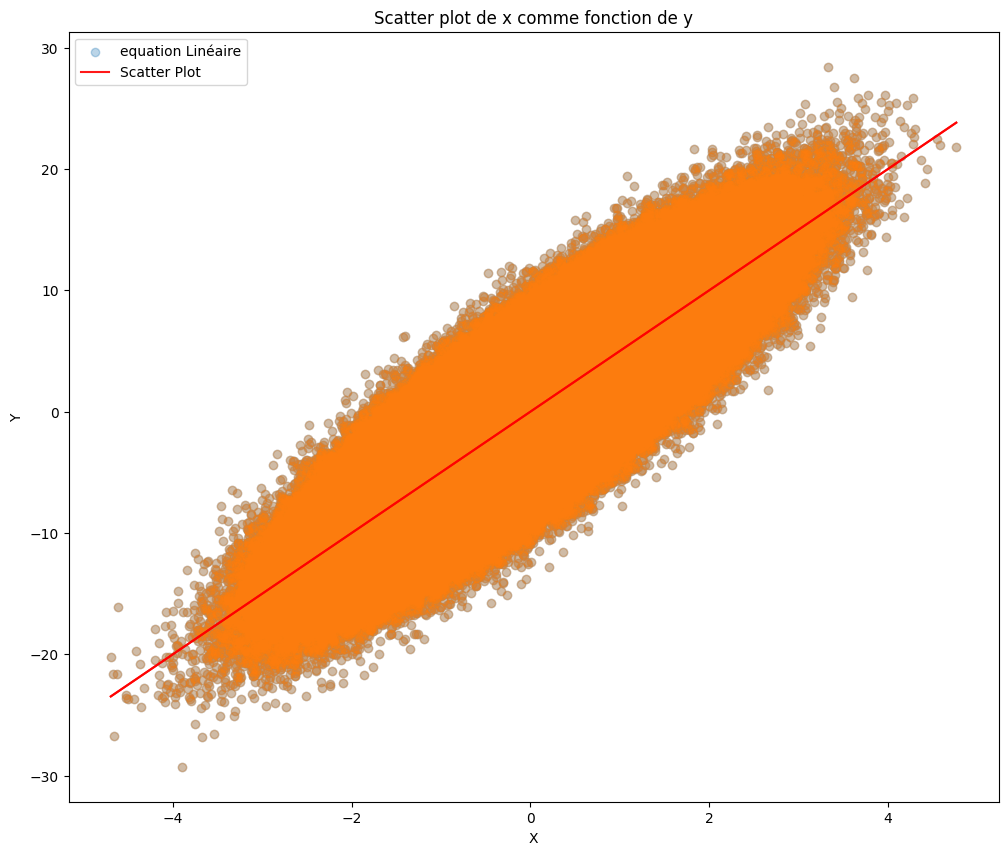

In [ ]:
# scatter plot of X and y
from statsmodels import regression
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 12, 10


import statsmodels.api as sm

def linreg(X,Y):
    # Running the linear regression
    X = sm.add_constant(X)  # adding a constant
    model = sm.OLS(Y, X).fit()
    a = model.params[0]
    b = model.params[1]
    X = X[:, 1]

    # 
    X2 = np.linspace(X.min(), X.max(), 100)
    Y_hat = a + b * X2
    plt.scatter(X, Y, alpha=0.3) # alpha transparence
    plt.plot(X2, Y_hat, 'r', alpha=0.9);  # Add the regression line, colored in red
    plt.xlabel('X Value')
    plt.ylabel('Y Value')
    return model.summary()

linreg(X, Y)
print(linreg(X,Y))

plt.title('Scatter plot de x comme fonction de y')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(['equation Linéaire', 'Scatter Plot'])

## La Matrice de Covariance 

La matrice de covariance entre $N$ actifs $X_1,\dots,X_N$ est donnée par :

$$ \Sigma = \left[\begin{matrix}
VAR(X_1) & COV(X_1, X_2) & \cdots & COV(X_1, X_N) \\
COV(X_2, X_1) & VAR(X_2) & \cdots & COV(X_2, X_N) \\
\vdots & \vdots & \ddots & \vdots \\
COV(X_N, X_1) & COV(X_N, X_2) & \cdots & VAR(X_N)
\end{matrix}\right].$$  

In [12]:
import pandas as pd
from datetime import datetime
from pandas_datareader import DataReader
from datetime import datetime
import yfinance as yf

start = datetime(2016,1,1)
end = datetime(2016,2,1)

symbol_list = ['SBUX', 'AAPL', 'GS', 'GILD']
returns = yf.download(symbol_list, start=start.strftime('%Y-%m-%d'), end=end.strftime('%Y-%m-%d'))['Close'].pct_change().dropna()  

print('Covariance matrix:')
print(returns.cov())

C:\Users\lione\AppData\Local\Temp\ipykernel_14292\1622695174.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  returns = yf.download(symbol_list, start=start.strftime('%Y-%m-%d'), end=end.strftime('%Y-%m-%d'))['Close'].pct_change().dropna()
[*********************100%***********************]  4 of 4 completed

Covariance matrix:
Ticker      AAPL      GILD        GS      SBUX
Ticker                                        
AAPL    0.000798  0.000264  0.000492  0.000358
GILD    0.000264  0.000550  0.000149  0.000074
GS      0.000492  0.000149  0.000568  0.000362
SBUX    0.000358  0.000074  0.000362  0.000474


## Pourquoi c'est important ?  


Nous mesurons la covariance des actifs de notre portefeuille pour nous assurer d'avoir une image précise des risques liés à la détention de ces actifs dans un même poertefeuille. Nous voulons répartir notre capital entre ces actifs de manière à minimiser notre exposition aux risques associés à chaque actif individuel et à neutraliser l'exposition au risque systématique. Cela se fait par le biais du processus d'optimisation du portefeuille. Les routines d'optimisation de portefeuille suivent exactement ce processus, trouvant les pondérations appropriées pour chaque actif compte tenu de ses risques. L'optimisation du rendement-variance, outil de base du MPT, fait exactement cela.

L'estimation de la matrice de covariance devient critique lors de l'utilisation de méthodes qui en dépendent, car nous ne pouvons pas connaître les véritables relations statistiques de nos actifs. La stabilité et l'exactitude de ces estimations sont essentielles pour obtenir des pondérations stables.


Malheureusement, la façon la plus évidente de calculer une estimation de matrice de covariance, la covariance d'échantillon, est instable. Si nous avons moins d'observations temporelles de nos actifs que le nombre d'actifs ($ T <N $), l'estimation devient particulièrement peu fiable. Les valeurs extrêmes réagissent plus fortement aux changements, et quand les valeurs extrêmes de la covariance sautent, nos optimiseurs sont perturbés, ce qui nous donne des poids incohérents. C'est un problème lorsque nous essayons de faire de nombreux investissements indépendants sur de nombreux actifs pour améliorer nos expositions au risque grâce à la diversification. Même si nous avons plus d'éléments temporels que d'actifs que nous négocions, nous pouvons rencontrer des problèmes, car la composante temporelle peut s'étendre sur plusieurs régimes, ce qui nous donne des matrices de covariance qui sont toujours inexactes.


Dans de nombreux cas, la solution consiste à utiliser une formulation robuste de la matrice de covariance. Si nous pouvons estimer une matrice de covariance qui capture toujours les relations entre les actifs et est simultanément plus stable, alors nous pouvons avoir plus confiance en nos optimiseurs. Une façon principale de gérer cela est d'utiliser une certaine forme shrinkage estimator.

# Shrinkage Estimators

La manière fondamentale de «rétrécir» une matrice est de réduire les valeurs extrêmes de la matrice de covariance de l'échantillon en les rapprochant du centre. Pratiquement, nous prenons une combinaison linéaire de la matrice de covariance-covariance empirique et un vecteur constant représentant le centre.

Etant donnée une matrice de covariance empirique $\textbf{S}$, la variance moyenne, $\mu$, et la constante de shrinkage $\delta$, la matrice de covariance shrinkée est  

$$
(1-\delta)\mathbf{S} + \delta \mu \mathbf{I}
$$

 
où $\delta$ such that $0 \leq \delta \leq 1$ fait un choix pondéré entre la covariance empirique et la variance ce qui en fait une moyenne pondérée entre la matrice de covariance de l'échantillon et la matrice de variance moyenne. La valeur optimale de $\delta$ est donnée par [Ledoit et Wolf](http://ledoit.net/honey.pdf).

## Estimateur Ledoit-Wolf .
 

$$\hat\delta^* :=\max\{0, \min\{\frac{\hat\kappa}{T},1\}\}$$

$\hat\kappa$  a une formulation mathématique qu'on peut trouver dans le papier.

L'estimateur de Ledoit-Wolf est un estimateur robuste pour estimer la covariance, voici comment l'implementer.

In [13]:
start = datetime(2016,1,1)
end = datetime(2016,2,1)

symbol_list = ["AAPL", "MSFT", "BRK-A", "GE", "FDX", "SBUX"]

returns = yf.download(symbol_list, start=start.strftime('%Y-%m-%d'), end=end.strftime('%Y-%m-%d'))['Close'].pct_change().dropna()  

C:\Users\lione\AppData\Local\Temp\ipykernel_14292\2899710089.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  returns = yf.download(symbol_list, start=start.strftime('%Y-%m-%d'), end=end.strftime('%Y-%m-%d'))['Close'].pct_change().dropna()
[*********************100%***********************]  6 of 6 completed


In [14]:
returns.head()

Ticker,AAPL,BRK-A,FDX,GE,MSFT,SBUX
Date,,,,,,
2016-01-05,-0.025059,0.003592,0.008506,0.000977,0.004562,0.006694
2016-01-06,-0.019570,0.002107,-0.026823,-0.015940,-0.018165,-0.008866
2016-01-07,-0.042204,-0.009295,-0.043902,-0.042314,-0.034783,-0.024772
2016-01-08,0.005287,-0.008590,0.000891,-0.017950,0.003067,-0.001058
2016-01-11,0.016193,-0.004332,-0.012916,0.004570,-0.000573,0.021014


On calcule ensuite le Ledoit-Wolf estimateur.

In [15]:
# ledoit_wolf estimator

in_sample_lw = covariance.ledoit_wolf(returns)[0]
print(in_sample_lw)

[[0.00070497 0.00015653 0.00030122 0.00021395 0.000443   0.00028162]
 [0.00015653 0.00021743 0.00018703 0.00013069 0.00017645 0.00016011]
 [0.00030122 0.00018703 0.00049121 0.00023085 0.00036247 0.0002626 ]
 [0.00021395 0.00013069 0.00023085 0.00034849 0.00024639 0.00025479]
 [0.000443   0.00017645 0.00036247 0.00024639 0.00054261 0.0002451 ]
 [0.00028162 0.00016011 0.0002626  0.00025479 0.0002451  0.00044935]]


### Calcul d'erreur

On peut quantifier la difference entre les vrais estimés et celles basées sur la covariance en calculant l'erreur: 

$$ \frac{1}{n} \sum_{i=1}^{n} |a_i - b_i| $$


In [16]:
start = datetime(2016,1,1)
end = datetime(2016,2,1)

oos_start = datetime(2016,2,1)
oos_end = datetime(2016,3,1)

oos_returns = yf.download(symbol_list, start=oos_start.strftime('%Y-%m-%d'), end=oos_end.strftime('%Y-%m-%d'))['Close'].pct_change().dropna()
out_sample_lw = covariance.ledoit_wolf(oos_returns)[0]
print(out_sample_lw)

C:\Users\lione\AppData\Local\Temp\ipykernel_14292\3510564990.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oos_returns = yf.download(symbol_list, start=oos_start.strftime('%Y-%m-%d'), end=oos_end.strftime('%Y-%m-%d'))['Close'].pct_change().dropna()
[*********************100%***********************]  6 of 6 completed

[[2.26223788e-04 5.53234401e-05 1.31285738e-04 1.09785228e-04
  1.22549708e-04 9.68310462e-05]
 [5.53234401e-05 1.59542859e-04 8.48615371e-05 6.60841622e-05
  8.09107308e-05 5.67293768e-05]
 [1.31285738e-04 8.48615371e-05 3.42504357e-04 1.96876232e-04
  1.47545331e-04 1.12148531e-04]
 [1.09785228e-04 6.60841622e-05 1.96876232e-04 2.51195053e-04
  1.27605343e-04 1.15651284e-04]
 [1.22549708e-04 8.09107308e-05 1.47545331e-04 1.27605343e-04
  2.85486398e-04 1.91170655e-04]
 [9.68310462e-05 5.67293768e-05 1.12148531e-04 1.15651284e-04
  1.91170655e-04 3.49213311e-04]]


In [ ]:
lw_errors = sum((in_sample_lw - out_sample_lw)**2).flatten()**0.5
print("Average Ledoit-Wolf error: ", np.mean(lw_errors))

Average Ledoit-Wolf error:  0.0003794471160971193


### Comparaison à l'estimation empirique


In [23]:
sample_errors = np.sum((returns.cov().values - oos_returns.cov().values)**2).flatten()**0.5
print('Average sample covariance error: ', np.mean(sample_errors))

Average sample covariance error:  0.0011753622746659845


In [24]:
print('Error improvement of LW over sample: {0:.2f}%'.format(np.mean(sample_errors/lw_errors)-1 * 100))

Error improvement of LW over sample: -96.44%


L'amélioration obtenue par le Ledoit-Wolf en comparant à une estimation empirique de la covariance est assez solide. Cela ce traduit par une décroissance de la volatilité et amélioration du rendement. 

In [25]:
sns.boxplot(
    data = pd.DataFrame({
        'Sample Covariance Error': sample_errors,
        'Ledoit-Wolf Error': lw_errors
    })
)
plt.title('Box Plot of Errors')
plt.ylabel('Error')

ValueError: All arrays must be of the same length

### Ajouter plus d'assets

Now we bring this to more assets over a longer time period. Let's see how the errors change over a series of months.

In [27]:
# a refaire avec un portefeuille plus important

start_date = datetime(2016,1,1)
end_date = datetime(2017,6,1)

symbols = [
    "SPY", "XLF", "XLE", "XLU","XLK", "XLI", "XLB", "GE", "GS", "BRK-A", "JPM", "AAPL", "MMM", "BA",
    "CSCO","KO", "DIS", "DD", "XOM", "INTC", "IBM", "NKE", "MSFT", "PG", "HD", "MCD", "CVX", 
    "AXP","JNJ", "MRK", "CAT", "PFE", "TRV", "UNH", "WMT", "VZ", "QQQ", "BAC", "F", "C", "CMCSA",
    "MS", "ORCL", "PEP", "HON", "GILD", "LMT", "UPS", "HP", "FDX", "GD", "SBUX"
]

returns = yf.download(symbols, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))['Close'].pct_change().dropna()

C:\Users\lione\AppData\Local\Temp\ipykernel_14292\3094500972.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  returns = yf.download(symbols, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))['Close'].pct_change().dropna()
[*********************100%***********************]  52 of 52 completed


In [28]:
dates = returns.resample("M").first().index

print(dates)

DatetimeIndex(['2016-01-31', '2016-02-29', '2016-03-31', '2016-04-30',
               '2016-05-31', '2016-06-30', '2016-07-31', '2016-08-31',
               '2016-09-30', '2016-10-31', '2016-11-30', '2016-12-31',
               '2017-01-31', '2017-02-28', '2017-03-31', '2017-04-30',
               '2017-05-31'],
              dtype='datetime64[ns]', name='Date', freq='ME')


C:\Users\lione\AppData\Local\Temp\ipykernel_14292\3529866691.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = returns.resample("M").first().index


On calcule les differentes estimation de la covariance.

In [29]:
sample_covs = []
lw_covs = []

for i in range(1, len(dates)):
    print(i)
    sample_cov = returns[dates[i-1]:dates[i]].cov().values
    sample_covs.append(sample_cov)
    
    lw_cov = covariance.ledoit_wolf(returns[dates[i-1]:dates[i]])[0]
    lw_covs.append(lw_cov)      
    
print(lw_covs)    

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
[array([[2.30707272e-04, 4.30017894e-05, 1.41291519e-04, ...,
        1.03418370e-04, 1.75533366e-06, 1.03132942e-04],
       [4.30017894e-05, 2.37114023e-04, 1.98802062e-04, ...,
        9.23333040e-05, 4.18144799e-05, 3.12823145e-05],
       [1.41291519e-04, 1.98802062e-04, 5.55276027e-04, ...,
        1.22421526e-04, 8.41157730e-05, 1.11732834e-04],
       ...,
       [1.03418370e-04, 9.23333040e-05, 1.22421526e-04, ...,
        1.84205089e-04, 9.81283762e-06, 3.79219996e-05],
       [1.75533366e-06, 4.18144799e-05, 8.41157730e-05, ...,
        9.81283762e-06, 1.43421070e-04, 1.04979216e-05],
       [1.03132942e-04, 3.12823145e-05, 1.11732834e-04, ...,
        3.79219996e-05, 1.04979216e-05, 2.75268385e-04]], shape=(52, 52)), array([[ 1.41835687e-04,  1.00505628e-05,  1.06087277e-05, ...,
         5.60475300e-05, -2.38936763e-06,  1.91083251e-05],
       [ 1.00505628e-05,  1.00229572e-04,  2.86292959e-05, ...,
         1.35442936e-05,  2.776689

On calcule l'erreur pour chaque période de temps.

In [30]:
lw_diffs = []
for pair in list(zip(lw_covs[:-1], lw_covs[1:])):
    diff = np.mean(np.sum(np.abs(pair[0] - pair[1])))
    lw_diffs.append(diff)
    
sample_diffs = []
for pair in list(zip(sample_covs[:-1], sample_covs[1:])):
    diff = np.mean(np.sum(np.abs(pair[0] - pair[1])))
    sample_diffs.append(diff)


On représente les erreurs au cours du temps.

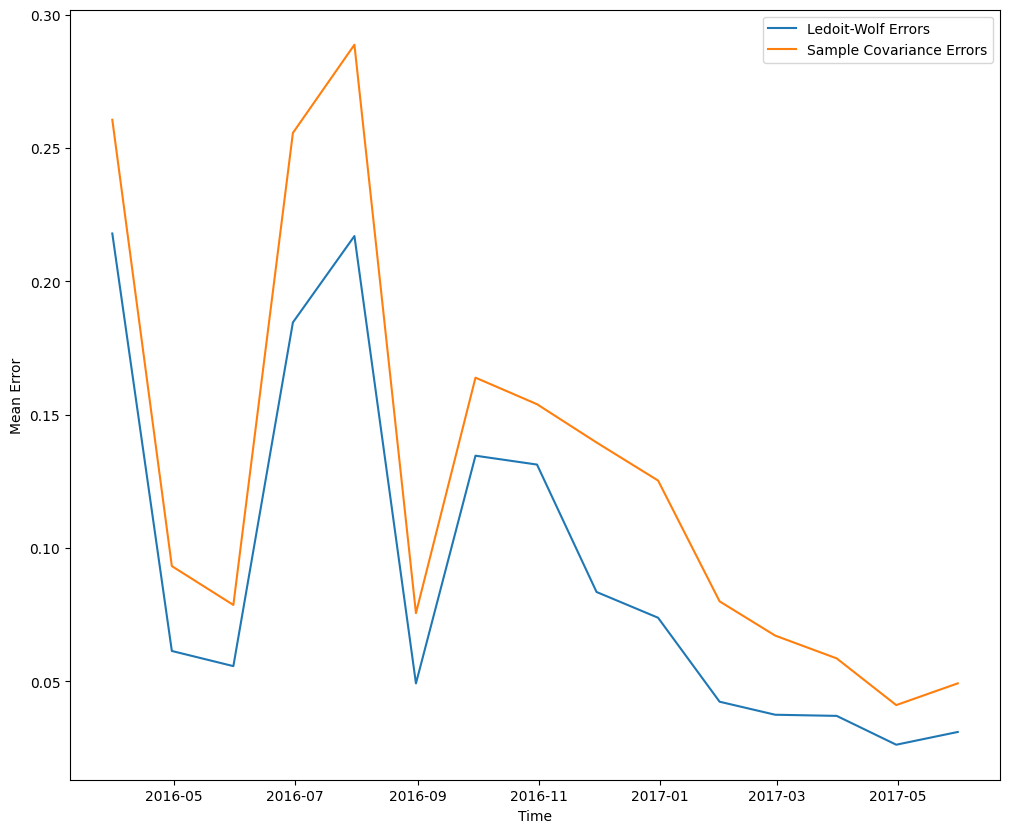

In [ ]:
plt.plot(dates[2:], lw_diffs)
plt.plot(dates[2:], sample_diffs)
plt.xlabel('Time')
plt.ylabel('Mean Error')
plt.legend(['Ledoit-Wolf Errors', 'Sample Covariance Errors'])